# This notebook is meant to test the basic functionality of the engine, including creating blocks, adding parameters, and running a workflow.

Imports

In [4]:
import sys
sys.path.append("..")  # Add parent directory to sys.path to allow imports
from ct_autodiff.engine.block import Block
from ct_autodiff.engine.workflow import Workflow

# Implement base classes:

Here we implement an example workflow with two blocks:
- A `ExampleBlock` that multiplies the input data by a slope parameter.
- A `ExampleBlock2` that adds an offset parameter to the input data.

This is basically implementing the function `f(x) = slope * x + offset` as a workflow, where `slope` and `offset` are learnable parameters of the two different blocks (in principle this can be one block but in order to test if gradients flow correctly we split it in 2). We will then create a workflow, add these blocks to it, and run the workflow on some input data to see the output. Then defining a simple loss function and running backpropagation we can see if the parameters are updated correctly.


In [5]:
class ExampleBlock(Block):
    def __init__(self):
        super().__init__(name="ExampleBlock")
        self.add_param(0.0, symbol="a", trainable=True)
    
    def execute(self, x):
        return self.a * x

class ExampleBlock2(Block):
    def __init__(self):
        super().__init__(name="ExampleBlock2")
        self.add_param(1.0, symbol="c", trainable=True)
    
    def execute(self, x):
        return x + self.c
    
class ExampleWorkflow(Workflow):
    def __init__(self):
        super().__init__(name="ExampleWorkflow")
        self.add_block(ExampleBlock())
        self.add_block(ExampleBlock2())

# Run and train workflow

ExampleWorkflow:
┌─────────────────────────────┐
│ ExampleBlock:               │
│     a: 0.0 (trainable=True) │
└─────────────────────────────┘
   │
   ▼
┌─────────────────────────────┐
│ ExampleBlock2:              │
│     c: 1.0 (trainable=True) │
└─────────────────────────────┘


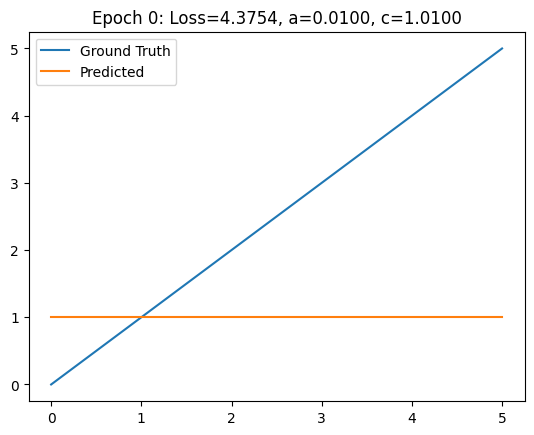

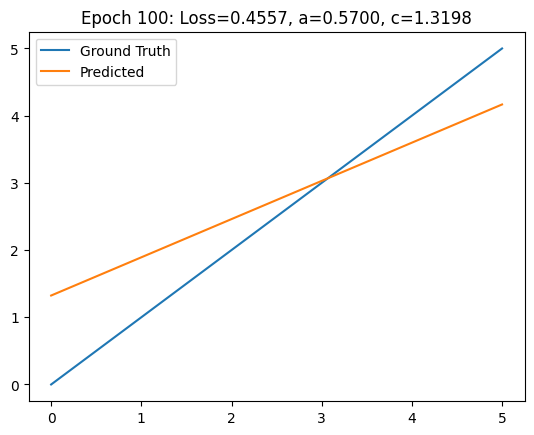

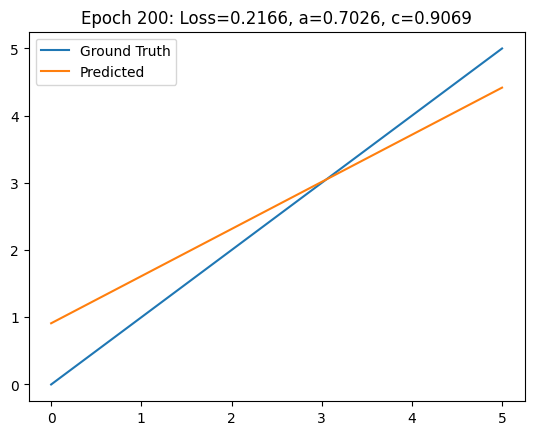

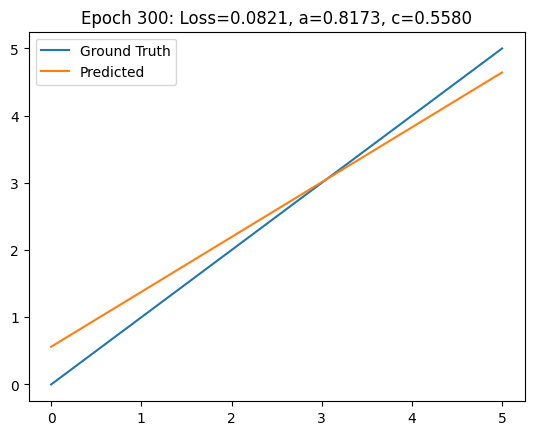

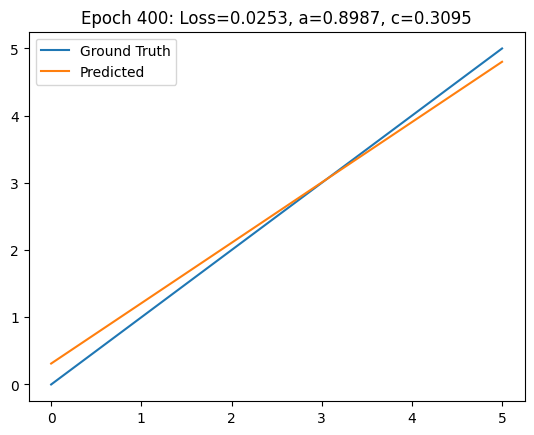

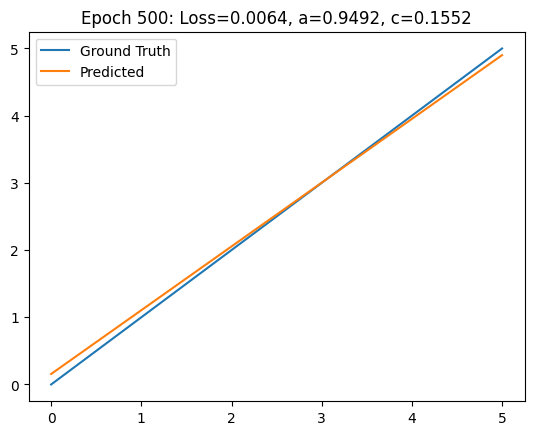

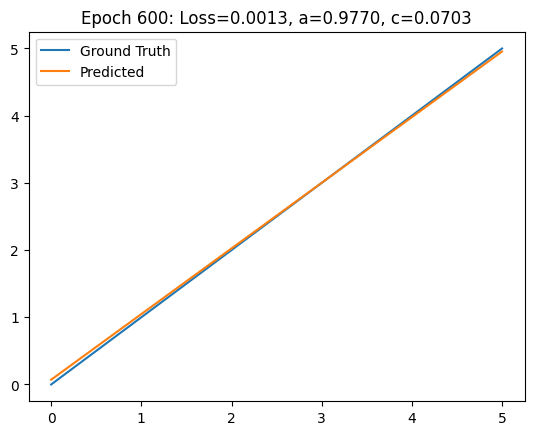

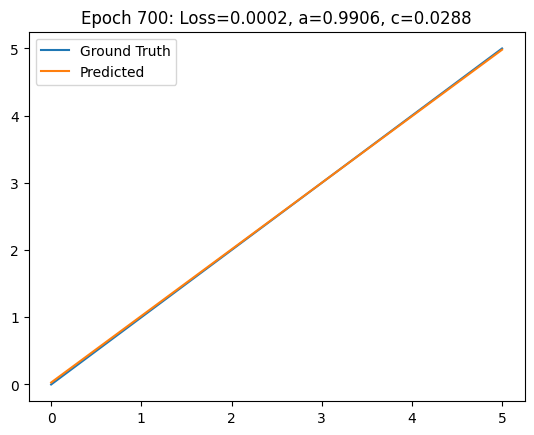

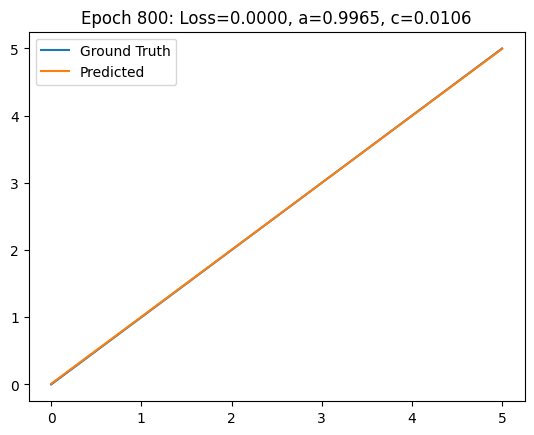

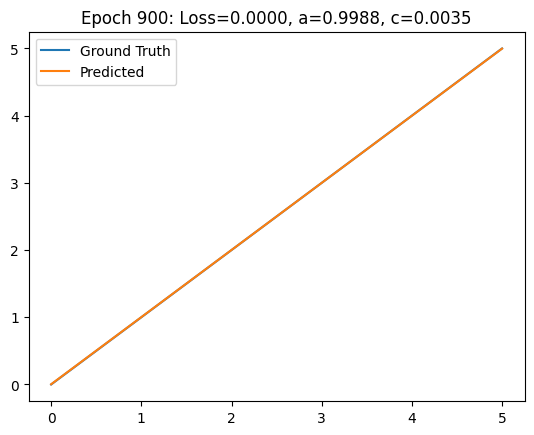

In [6]:
# Generate some test data
import torch
import matplotlib.pyplot as plt

workflow = ExampleWorkflow()
print(workflow)
workflow = workflow.to("cuda" if torch.cuda.is_available() else "cpu")

x = torch.linspace(0, 5, steps=100)
x = x.to("cuda" if torch.cuda.is_available() else "cpu")
y_gt = 1.0 * x + 0.0

loss_fn = torch.nn.MSELoss()
adam = torch.optim.Adam(workflow.parameters(), lr=0.01)

for epoch in range(1000):
    y_pred = workflow.run(x)
    loss = loss_fn(y_pred, y_gt)
    
    adam.zero_grad()
    loss.backward()
    adam.step()
    
    if epoch % 100 == 0:
        plt.plot(x.cpu(), y_gt.cpu(), label="Ground Truth")
        plt.plot(x.cpu(), y_pred.detach().cpu(), label="Predicted")
        plt.title(f"Epoch {epoch}: Loss={loss.item():.4f}, a={workflow.blocks[0].a.item():.4f}, c={workflow.blocks[1].c.item():.4f}")
        plt.legend()
        plt.show()